# ManyWell High-Dimensional Experiment


## Problem setup and target geometry

### Per-block potential

The ManyWell target is a product of $16$ identical, independent $2$D blocks.
Each block has a *double-well* coordinate $d$ and a *Gaussian* coordinate $v$,
with energy

$$U(d,v) = a\,d + b\,d^2 + c\,d^4 + \tfrac12 v^2,
\qquad a=-0.5,\; b=-6.0,\; c=1.0 .$$

The full state stacks the $16$ blocks,

$$x = (d_1,v_1,d_2,v_2,\dots,d_{16},v_{16}) \in \mathbb{R}^{32},$$

so **even** coordinates $x_{2j}=d_j$ are double-well coordinates and **odd**
coordinates $x_{2j+1}=v_j$ are Gaussian coordinates. The full energy and target
density are

$$U(x) = \sum_{j=1}^{16}\Big(a\,d_j + b\,d_j^2 + c\,d_j^4 + \tfrac12 v_j^2\Big),
\qquad \pi(x)\propto e^{-U(x)} .$$

### Analytic force (no autograd)

Because $U$ is separable and polynomial we use the closed-form gradient. With
$U_d(d)=a d + b d^2 + c d^4$,

$$\partial_d U = a + 2b\,d + 4c\,d^3,\qquad \partial_v U = v,
\qquad \nabla\log\pi = -\nabla U .$$

So the force on a double-well coordinate is $-(a+2bd+4cd^3)$ and on a Gaussian
coordinate is $-v$.

### Well geometry

The 1D double-well potential $U_d(d)=a d + b d^2 + c d^4$ has stationary
points where $U_d'(d)=4c\,d^3 + 2b\,d + a = 0$, a cubic we solve with
`np.roots`. The two outer roots ($U_d''>0$) are the **left (shallow)** and
**right (deep)** wells; the inner root ($U_d''<0$) is the **saddle / barrier
top**. The linear term $a d=-0.5\,d$ tilts the potential so the right well is
deeper, making the two wells **unequally weighted** — this is what makes the
mode metrics below non-trivial.


In [1]:
import os
# Use a free GPU (GPU 0 is shared on this box); fall back gracefully if absent.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "1")

import math, time, json, warnings
from pathlib import Path
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import linear_sum_assignment
from scipy.stats import binom

warnings.filterwarnings("ignore")
torch.set_grad_enabled(False)            # analytic force only — no autograd anywhere

# ── Paper plotting style (fall back to sane defaults if unavailable) ──────────
try:
    plt.style.use("paper.mplstyle")
    print("Loaded paper.mplstyle")
except Exception as e:
    matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 11,
                                "axes.grid": True, "grid.alpha": 0.3})
    print(f"paper.mplstyle not used ({e}); using defaults")

METHOD_COLORS = {"ULA": "steelblue", "MALA": "darkorange",
                 "FLMC": "seagreen", "LSBMC": "firebrick"}
METHODS = ["ULA", "MALA", "FLMC", "LSBMC"]

# ── Single output directory for ALL figures + numerical results ──────────────
OUT = Path("manywell_output"); OUT.mkdir(exist_ok=True)

# ── Device ───────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE  = torch.float32
if device.type == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"Device: {p.name} | {p.total_memory/1e9:.1f} GB | CUDA {torch.version.cuda}")
else:
    print("Device: CPU (CUDA unavailable) — settings will be scaled down.")

# ── Target coefficients ──────────────────────────────────────────────────────
A_COEF, B_COEF, C_COEF = -0.5, -6.0, 1.0

def U1d_np(d):
    """1D double-well potential U_d(d) = a d + b d^2 + c d^4 (numpy)."""
    return A_COEF*d + B_COEF*d**2 + C_COEF*d**4

# ============================ EXPERIMENT SETTINGS =============================
DIM       = 32
N_WELLS   = DIM // 2                         # 16 blocks

N_SEEDS   = 5
SEEDS     = [0, 1, 2, 3, 4]
GLOBAL_SEED = 0

N_PARTICLES = 8192                           # try 16384 if you want; H200 has room
N_REF       = 20000

DT          = 0.005
T_END       = 20.0
N_STEPS     = int(T_END / DT)
METRIC_EVERY = 100

# Metric subsample sizes
W2_SUB  = 256
MMD_SUB = 1024
MMD_MULTS = [0.25, 0.5, 1.0, 2.0, 4.0]

# FLMC
ALPHA = 1.5
FLMC_XI_CLIP = 100.0

# LSBMC jump law (the ONLY jump range used)
LAMBDA_BLOCK = 0.1
JUMP_R_MIN, JUMP_R_MAX = 3.2, 3.8

# MALA
MALA_DT = 0.005

# Numerical safeguards
STATE_CLIP = 10.0

# Reference inverse-CDF grid
D_GRID_MIN, D_GRID_MAX, D_GRID_SIZE = -5.0, 5.0, 200_001

# Lévy score precomputation grid
LEVY_SCORE_GRID_MIN, LEVY_SCORE_GRID_MAX, LEVY_SCORE_GRID_SIZE = -5.0, 5.0, 20_001
N_QUAD = 256

# CPU fallback: keep the notebook runnable but quick
if device.type != "cuda":
    N_PARTICLES, N_REF, T_END = 1024, 4000, 6.0
    N_STEPS = int(T_END / DT)

print(f"DIM={DIM}, blocks={N_WELLS}, particles={N_PARTICLES}, seeds={N_SEEDS}")
print(f"dt={DT}, T_END={T_END}, steps={N_STEPS}, metric_every={METRIC_EVERY}")
print(f"jump r~U[{JUMP_R_MIN},{JUMP_R_MAX}], lambda_block={LAMBDA_BLOCK}")


Loaded paper.mplstyle
Device: NVIDIA H200 NVL | 150.1 GB | CUDA 13.0
DIM=32, blocks=16, particles=8192, seeds=5
dt=0.005, T_END=20.0, steps=4000, metric_every=100
jump r~U[3.2,3.8], lambda_block=0.1


In [2]:
# ── Analytic target: energy, log_prob, force ─────────────────────────────────
# All accept x of shape (..., DIM) where even coords are d_j, odd coords are v_j.

def energy(x):
    """U(x) summed over the 16 blocks.  (..., DIM) -> (...)."""
    d = x[..., 0::2]
    v = x[..., 1::2]
    Ud = A_COEF*d + B_COEF*d**2 + C_COEF*d**4
    return Ud.sum(-1) + 0.5*(v**2).sum(-1)

def log_prob(x):
    """log pi(x) up to an additive constant = -U(x)."""
    return -energy(x)

def force(x):
    """force = grad log pi = -grad U.  (..., DIM) -> (..., DIM)."""
    d = x[..., 0::2]
    v = x[..., 1::2]
    f = torch.empty_like(x)
    f[..., 0::2] = -(A_COEF + 2*B_COEF*d + 4*C_COEF*d**3)
    f[..., 1::2] = -v
    return f

# ── Shape sanity check ───────────────────────────────────────────────────────
_xt = torch.randn(3, 7, DIM, device=device, dtype=DTYPE)
assert energy(_xt).shape   == (3, 7),       energy(_xt).shape
assert log_prob(_xt).shape == (3, 7),       log_prob(_xt).shape
assert force(_xt).shape    == (3, 7, DIM),  force(_xt).shape
print("shape checks passed:",
      "energy", tuple(energy(_xt).shape),
      "| force", tuple(force(_xt).shape))
del _xt


shape checks passed: energy (3, 7) | force (3, 7, 32)


In [3]:
# ── Stationary points of the 1D double well ──────────────────────────────────
# Solve U_d'(d) = 4 c d^3 + 2 b d + a = 0.
_roots = np.roots([4*C_COEF, 0.0, 2*B_COEF, A_COEF])
_real  = np.sort(_roots[np.abs(_roots.imag) < 1e-9].real)
assert len(_real) == 3, f"expected 3 real roots, got {_real}"
D_LEFT, D_SADDLE, D_RIGHT = float(_real[0]), float(_real[1]), float(_real[2])

def _curv(d):  # U_d''(d) = 2b + 12 c d^2  (>0 => well, <0 => saddle)
    return 2*B_COEF + 12*C_COEF*d**2

U_left, U_saddle, U_right = U1d_np(D_LEFT), U1d_np(D_SADDLE), U1d_np(D_RIGHT)
barrier_from_left  = U_saddle - U_left
barrier_from_right = U_saddle - U_right

print("1D double-well stationary points  U_d(d) = a d + b d^2 + c d^4")
print(f"  left  (shallow) well : d = {D_LEFT:+.5f}   U_d = {U_left:+.4f}   U'' = {_curv(D_LEFT):+.2f}")
print(f"  saddle (barrier top) : d = {D_SADDLE:+.5f}   U_d = {U_saddle:+.4f}   U'' = {_curv(D_SADDLE):+.2f}")
print(f"  right (deep)    well : d = {D_RIGHT:+.5f}   U_d = {U_right:+.4f}   U'' = {_curv(D_RIGHT):+.2f}")
print(f"  well separation D_RIGHT - D_LEFT = {D_RIGHT - D_LEFT:.4f}")
print(f"  barrier height from left  well   = {barrier_from_left:.4f}")
print(f"  barrier height from right well   = {barrier_from_right:.4f}")
print(f"  right well is deeper by          = {U_left - U_right:.4f}")
assert _curv(D_LEFT) > 0 and _curv(D_RIGHT) > 0 and _curv(D_SADDLE) < 0
print("\nJump range [%.1f, %.1f] brackets the well separation %.3f -> good." %
      (JUMP_R_MIN, JUMP_R_MAX, D_RIGHT - D_LEFT))


1D double-well stationary points  U_d(d) = a d + b d^2 + c d^4
  left  (shallow) well : d = -1.71083   U_d = -8.1392   U'' = +23.12
  saddle (barrier top) : d = -0.04169   U_d = +0.0104   U'' = -11.98
  right (deep)    well : d = +1.75252   U_d = -9.8712   U'' = +24.86
  well separation D_RIGHT - D_LEFT = 3.4633
  barrier height from left  well   = 8.1497
  barrier height from right well   = 9.8816
  right well is deeper by          = 1.7319

Jump range [3.2, 3.8] brackets the well separation 3.463 -> good.


## Exact reference sampler

Because $\pi$ factorizes across the $16$ blocks and across $d$ vs. $v$ within a
block, an (essentially) exact reference sample is cheap:

* each Gaussian coordinate is drawn directly, $v_j \sim \mathcal N(0,1)$;
* each double-well coordinate is drawn from
  $\pi_d(d)\propto e^{-U_d(d)}$ by **numerical inverse-CDF** on a fine grid
  $d\in[-5,5]$ with $200{,}001$ nodes.

We build the normalized density $\pi_d$ and its CDF on the CPU in `float64`,
draw uniforms, invert by interpolation, then assemble the $32$D state and move
it to the GPU. From the same grid we compute the **true deep-well probability**

$$p_{\mathrm{deep}} = \mathbb P(d > d_{\mathrm{saddle}}) = \int_{d_{\mathrm{saddle}}}^{\infty}\pi_d(d)\,dd ,$$

which is the key quantity for all mode metrics: under the target the number of
deep wells per sample is $K\sim\mathrm{Binomial}(16, p_{\mathrm{deep}})$.


In [4]:
# ── Build the 1D inverse-CDF for pi_d(d) ∝ exp(-U_d(d)) on a fine grid ────────
_dg    = np.linspace(D_GRID_MIN, D_GRID_MAX, D_GRID_SIZE)          # (G,)
_logp  = -U1d_np(_dg)
_logp -= _logp.max()                                              # stability
_pd    = np.exp(_logp)
_Z     = np.trapezoid(_pd, _dg)
_pd_n  = _pd / _Z                                                 # normalized density
_dx    = _dg[1] - _dg[0]
_cdf   = np.concatenate([[0.0], np.cumsum(0.5*(_pd_n[:-1] + _pd_n[1:]) * _dx)])

# True deep-well probability P(d > d_saddle)
_mask_deep = _dg > D_SADDLE
P_DEEP = float(np.trapezoid(_pd_n[_mask_deep], _dg[_mask_deep]))
print(f"p_deep = P(d > d_saddle={D_SADDLE:.4f}) = {P_DEEP:.5f}")
print(f"  (so p_shallow = {1 - P_DEEP:.5f}; right well carries most mass)")

def sample_reference(n_samples, dim=DIM, device=device, dtype=DTYPE, seed=0):
    """Exact iid reference sample from pi. Builds d via inverse-CDF (CPU), v ~ N(0,1)."""
    rng   = np.random.default_rng(seed)
    nw    = dim // 2
    u     = rng.uniform(0.0, _cdf[-1], size=(n_samples, nw))
    d     = np.interp(u.ravel(), _cdf, _dg).reshape(n_samples, nw)
    v     = rng.standard_normal((n_samples, nw))
    x     = np.empty((n_samples, dim), dtype=np.float64)
    x[:, 0::2] = d
    x[:, 1::2] = v
    return torch.tensor(x, device=device, dtype=dtype)

X_REF = sample_reference(N_REF, seed=12345)
print(f"X_REF.shape = {tuple(X_REF.shape)} on {X_REF.device}")

# Sanity: empirical P(d > d_saddle) of the reference vs analytic p_deep
_emp_deep = (X_REF[:, 0::2] > D_SADDLE).float().mean().item()
print(f"reference empirical P(d>saddle) = {_emp_deep:.5f}  vs  p_deep = {P_DEEP:.5f}  "
      f"(|diff| = {abs(_emp_deep - P_DEEP):.4f})")
assert abs(_emp_deep - P_DEEP) < 0.01, "reference sampler deep-well fraction off"

# Precompute target distributions used by the mode metrics
H_BERN   = -(P_DEEP*math.log(P_DEEP) + (1-P_DEEP)*math.log(1-P_DEEP))  # Bernoulli entropy
H_TARGET = N_WELLS * H_BERN                                            # target binary entropy
BINOM_PMF = binom.pmf(np.arange(N_WELLS + 1), N_WELLS, P_DEEP)         # K ~ Binom(16, p_deep)
print(f"Bernoulli entropy h(p_deep) = {H_BERN:.4f} nats | H_target = {H_TARGET:.4f} nats")


p_deep = P(d > d_saddle=-0.0417) = 0.84431
  (so p_shallow = 0.15569; right well carries most mass)
X_REF.shape = (20000, 32) on cuda:0
reference empirical P(d>saddle) = 0.84445  vs  p_deep = 0.84431  (|diff| = 0.0001)
Bernoulli entropy h(p_deep) = 0.4325 nats | H_target = 6.9192 nats


## Metrics

We track exactly three metrics, all computed **per seed** (the seed axis gives
independent replicates) and reported as mean $\pm$ standard error over seeds.

**A. Wasserstein-2 ($W_2$).** Exact empirical optimal transport on random
subsamples of size $M=$ `W2_SUB`: build the $M\times M$ squared-distance matrix on
the GPU and solve the assignment with `scipy.optimize.linear_sum_assignment`,
$W_2=\big(\tfrac1M\sum_i\lVert x_i-y_{\sigma(i)}\rVert^2\big)^{1/2}$. At $M=256$ the
exact OT is cheap, so an entropic (Sinkhorn) approximation is unnecessary here; it
could be swapped in for much larger $M$.

**B. MMD (multi-kernel Gaussian).** Biased $V$-statistic
$\widehat{\mathrm{MMD}}^2=\overline{k_{XX}}+\overline{k_{YY}}-2\,\overline{k_{XY}}$
with $k(a,b)=\exp(-\lVert a-b\rVert^2/2h^2)$ on subsamples of size `MMD_SUB`. The
base bandwidth $h_0$ is the median pairwise distance of the pooled subsample; we
average $\mathrm{MMD}^2$ over $h\in\{0.25,0.5,1,2,4\}\,h_0$ and report
$\sqrt{\max(\cdot,0)}$.

**C. Entropic mode coverage (EMC)** — the form for an **imbalanced** target
(arXiv:2406.07423, App. A.3). The mode descriptors are the $M=2^{16}$ deep/shallow
block configurations (a block is *deep* iff $d_j>d_{\mathrm{saddle}}$). Let
$\hat p_{\mathrm{mode}}$ be the empirical distribution over configurations and
$p^\star_{\mathrm{mode}}$ the **target** mode distribution. Because the $16$ blocks
are independent, $p^\star_{\mathrm{mode}}$ is a product of
Bernoulli$(p_{\mathrm{deep}})$, so a configuration with $k$ deep blocks has
$p^\star = p_{\mathrm{deep}}^{\,k}\,(1-p_{\mathrm{deep}})^{16-k}$. Then
$$\mathrm{EMC} \;=\; \exp\!\big(-\,\mathrm{KL}(\hat p_{\mathrm{mode}}\,\|\,p^\star_{\mathrm{mode}})\big)\;\in(0,1].$$
$\mathrm{EMC}=1$ iff the empirical mode distribution matches the target exactly;
$\mathrm{EMC}\to0$ under severe mode collapse or a wrong mode distribution.
**Larger is better.** Unlike a raw entropy, this compares the mode distribution
*to the target*, so spreading mass onto the wrong configurations (over-dispersion)
is **penalized**, not rewarded. With finite $N$, even an exact sample gives
$\mathrm{KL}>0$, so the achievable ceiling is the exact-sample floor `REF*`.

> Each metric is also evaluated **reference-vs-reference** to obtain the
> finite-sample **floor** `REF*` — the best value attainable at these subsample
> sizes (in 32-D, $W_2,\mathrm{MMD}>0$ and $\mathrm{EMC}<1$ even for exact samples).


In [5]:
# ── Metrics: (A) exact W2, (B) multi-kernel MMD, (C) entropic mode coverage ──

def global_w2(xs, ys):
    """Exact empirical W2 between equal-size GPU subsamples xs, ys (M, DIM).
    Cost matrix built on GPU; optimal assignment solved on CPU (Hungarian)."""
    C = (torch.cdist(xs, ys) ** 2).cpu().numpy()
    ri, ci = linear_sum_assignment(C)
    return math.sqrt(C[ri, ci].mean())

def mmd_multikernel(X, Y, mults=MMD_MULTS):
    """Biased multi-kernel Gaussian MMD^2 (mean over bandwidths), GPU. X,Y:(m,d)."""
    Dxx = torch.cdist(X, X); Dyy = torch.cdist(Y, Y); Dxy = torch.cdist(X, Y)
    pool = torch.cat([X, Y], dim=0)
    Dpp  = torch.cdist(pool, pool)
    N    = pool.shape[0]
    iu   = torch.triu_indices(N, N, 1, device=X.device)
    base = Dpp[iu[0], iu[1]].median().clamp_min(1e-6)          # median heuristic
    out  = 0.0
    for mu in mults:
        h2  = 2.0 * (base * mu) ** 2
        kxx = torch.exp(-Dxx ** 2 / h2).mean()
        kyy = torch.exp(-Dyy ** 2 / h2).mean()
        kxy = torch.exp(-Dxy ** 2 / h2).mean()
        out = out + (kxx + kyy - 2 * kxy)
    return float(out / len(mults))

_POW2     = (2 ** torch.arange(N_WELLS, device=device)).long()   # binary mode codes
_LOG_PD   = math.log(P_DEEP)
_LOG_QD   = math.log1p(-P_DEEP)                                  # log(1 - p_deep)

def entropic_mode_coverage(xs):
    """EMC for the imbalanced ManyWell target (arXiv:2406.07423, App. A.3):
        EMC = exp( -KL( p_hat_mode || p_star_mode ) )   in (0, 1].
    Mode descriptors = the 2^16 deep/shallow block configurations (block deep iff
    d_j > d_saddle).  p_hat_mode is the empirical distribution over observed configs;
    p_star_mode is the analytic target = product of Bernoulli(p_deep) over the 16
    independent blocks, so a config with k deep blocks has
        p_star = p_deep^k (1 - p_deep)^(16 - k).
    EMC = 1 iff the empirical mode distribution exactly matches the target;
    EMC ~ 0 under mode collapse / a wrong mode distribution.  Larger is better."""
    deep  = xs[:, 0::2] > D_SADDLE
    codes = (deep.long() * _POW2).sum(dim=1)                      # (N,) in [0, 2^16)
    uniq, counts = torch.unique(codes, return_counts=True)       # observed configs
    p_hat = counts.float() / counts.sum()
    # popcount(uniq) = number of deep blocks k for each observed configuration
    k = torch.zeros_like(uniq); u = uniq.clone()
    for _ in range(N_WELLS):
        k += (u & 1); u >>= 1
    log_pstar = k.float() * _LOG_PD + (N_WELLS - k).float() * _LOG_QD
    kl = (p_hat * (torch.log(p_hat) - log_pstar)).sum().item()   # KL(p_hat || p_star)
    return math.exp(-kl)

def compute_metrics(x):
    """x:(N_SEEDS, N_PARTICLES, DIM) -> dict of per-seed arrays {w2, mmd, emc}."""
    res = {"w2": [], "mmd": [], "emc": []}
    for s in range(x.shape[0]):
        xs = x[s]
        ip = torch.randperm(xs.shape[0], device=device)[:W2_SUB]
        ir = torch.randperm(N_REF,        device=device)[:W2_SUB]
        res["w2"].append(global_w2(xs[ip], X_REF[ir]))
        jp = torch.randperm(xs.shape[0], device=device)[:MMD_SUB]
        jr = torch.randperm(N_REF,        device=device)[:MMD_SUB]
        res["mmd"].append(math.sqrt(max(mmd_multikernel(xs[jp], X_REF[jr]), 0.0)))
        res["emc"].append(entropic_mode_coverage(xs))
    return {k: np.array(v) for k, v in res.items()}

# Reference-vs-reference self-consistency = finite-sample FLOOR (best achievable).
_x_test = sample_reference(N_PARTICLES, seed=7)[None].repeat(2, 1, 1)
_m = compute_metrics(_x_test)
REF_FLOOR = {k: float(_m[k].mean()) for k in ["w2", "mmd", "emc"]}
print("self-consistency floor (exact reference vs reference, same subsample sizes):")
for k in ["w2", "mmd", "emc"]:
    print(f"  {k:4s} = {REF_FLOOR[k]:.4f}")
print("EMC = exp(-KL(p_hat_mode || p_star_mode)) in (0,1]: 1 = exact match, "
      "larger is better; the exact-sample floor above is the finite-sample ceiling.")
del _x_test


self-consistency floor (exact reference vs reference, same subsample sizes):
  w2   = 6.2551
  mmd  = 0.0315
  emc  = 0.6589
EMC = exp(-KL(p_hat_mode || p_star_mode)) in (0,1]: 1 = exact match, larger is better; the exact-sample floor above is the finite-sample ceiling.


##  Lévy score for coordinate-wise well jumps

LSBMC adds compound-Poisson jumps that act **only on the double-well
coordinate** $d_j$ (never on $v_j$): $d_j \leftarrow d_j + s\,r$, with sign
$s\in\{-1,+1\}$ uniform and radius $r\sim\mathrm{Uniform}(r_0,R)$,
$r_0=3.2,\;R=3.8$, at per-block rate $\lambda_{\mathrm{block}}=0.1$.

To keep the perturbed dynamics stationary for $\pi$, the drift carries a
**Lévy score** correction. Because the jump kernel is a product over blocks and
acts on a single coordinate, the $32$D score is fully determined by a **single
one-dimensional function** of $d$ — no $32$D integral is ever needed. With
$U_d(d)=a d + b d^2 + c d^4$,

$$S_L(d) = \frac{\lambda_{\mathrm{block}}}{2(R-r_0)}
\int_0^R w(u)\Big[e^{\,U_d(d)-U_d(d+u)} - e^{\,U_d(d)-U_d(d-u)}\Big]\,du,
\qquad
w(u)=\begin{cases} R-r_0, & 0\le u\le r_0,\\ R-u, & r_0<u\le R.\end{cases}$$

The full-state score sets $S_L(x)_{2j}=S_L(d_j)$ and $S_L(x)_{2j+1}=0$.

**Implementation.** We evaluate $S_L$ once on a grid of $20{,}001$ points in
`float64` using Gauss–Legendre quadrature ($N_{\text{quad}}=256$ nodes per
panel, split at the kink $u=r_0$), clip exponent arguments to $[-60,60]$ and the
final score to $[-100,100]$, then move the grid to the GPU as `float32`. At run
time `torch.bucketize` gives fast linear interpolation.


In [6]:
# ── Precompute the 1D Levy score on a grid (float64), then move to GPU float32 ─
def precompute_levy_score_grid():
    d = torch.linspace(LEVY_SCORE_GRID_MIN, LEVY_SCORE_GRID_MAX,
                       LEVY_SCORE_GRID_SIZE, dtype=torch.float64)
    nodes, wts = np.polynomial.legendre.leggauss(N_QUAD)
    nodes = torch.tensor(nodes, dtype=torch.float64)
    wts   = torch.tensor(wts,   dtype=torch.float64)

    def panel(lo, hi):
        u  = 0.5 * (hi - lo) * nodes + 0.5 * (hi + lo)     # nodes in [lo,hi]
        wq = 0.5 * (hi - lo) * wts
        return u, wq

    u1, w1 = panel(0.0, JUMP_R_MIN)            # weight = R - r0 (constant)
    u2, w2 = panel(JUMP_R_MIN, JUMP_R_MAX)     # weight = R - u
    u  = torch.cat([u1, u2])                   # (2*N_QUAD,)
    wq = torch.cat([w1, w2])
    Wu = torch.where(u <= JUMP_R_MIN,
                     torch.full_like(u, JUMP_R_MAX - JUMP_R_MIN),
                     JUMP_R_MAX - u)

    def U1d_t(dd):
        return A_COEF*dd + B_COEF*dd**2 + C_COEF*dd**4

    dc  = d[:, None]                           # (G,1)
    uu  = u[None, :]                           # (1,Q)
    Ud  = U1d_t(dc)
    ep  = torch.exp(torch.clamp(Ud - U1d_t(dc + uu), -60.0, 60.0))   # exp(U(d)-U(d+u))
    em  = torch.exp(torch.clamp(Ud - U1d_t(dc - uu), -60.0, 60.0))   # exp(U(d)-U(d-u))
    integ = ((wq * Wu)[None, :] * (ep - em)).sum(dim=1)              # (G,)
    S = LAMBDA_BLOCK / (2.0 * (JUMP_R_MAX - JUMP_R_MIN)) * integ
    S = S.clamp(-100.0, 100.0)
    return d.to(DTYPE).to(device), S.to(DTYPE).to(device)

D_GRID_T, S_GRID_T = precompute_levy_score_grid()
assert torch.isfinite(S_GRID_T).all(), "Levy score grid has non-finite values!"
print(f"Levy score grid: {S_GRID_T.numel()} pts | "
      f"range [{S_GRID_T.min().item():.3f}, {S_GRID_T.max().item():.3f}]")

def interp_1d_torch(q, grid, vals):
    """Linear interpolation of (grid, vals) at query points q (any shape)."""
    G   = grid.shape[0]
    idx = torch.bucketize(q, grid).clamp(1, G - 1)
    x0, x1 = grid[idx - 1], grid[idx]
    y0, y1 = vals[idx - 1], vals[idx]
    w = (q - x0) / (x1 - x0)
    return y0 + w * (y1 - y0)

def levy_score(x, grid=D_GRID_T, vals=S_GRID_T):
    """Full-state Levy score: S on even (double-well) coords, 0 on odd coords."""
    out = torch.zeros_like(x)
    out[..., 0::2] = interp_1d_torch(x[..., 0::2], grid, vals)
    return out


Levy score grid: 20001 pts | range [-100.000, 100.000]


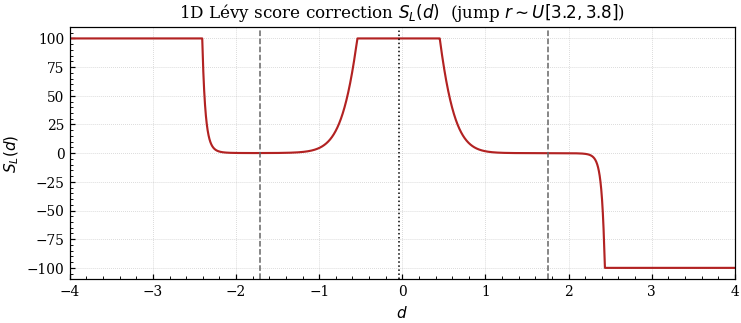

S_L at left well  d=-1.711:  +0.0893
S_L at right well d=+1.753:  -0.0053
score finite: True


In [7]:
# ── Visual + numeric sanity check of the Levy score grid ─────────────────────
_dn = D_GRID_T.cpu().numpy(); _sn = S_GRID_T.cpu().numpy()
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(_dn, _sn, color="firebrick", lw=1.4)
ax.axvline(D_LEFT,   color="0.4", ls="--", lw=1.0)
ax.axvline(D_RIGHT,  color="0.4", ls="--", lw=1.0)
ax.axvline(D_SADDLE, color="k",   ls=":",  lw=1.0)
ax.set_xlim(-4, 4); ax.set_xlabel("$d$"); ax.set_ylabel("$S_L(d)$")
ax.set_title("1D Lévy score correction $S_L(d)$  (jump $r\\sim U[3.2,3.8]$)")
fig.tight_layout(); plt.show(); plt.close(fig)
print(f"S_L at left well  d={D_LEFT:+.3f}:  {np.interp(D_LEFT,  _dn, _sn):+.4f}")
print(f"S_L at right well d={D_RIGHT:+.3f}:  {np.interp(D_RIGHT, _dn, _sn):+.4f}")
print("score finite:", np.isfinite(_sn).all())


## GPU implementation of samplers

Every sampler operates on the state tensor `x` of shape
`(N_SEEDS, N_PARTICLES, DIM)`; all particles and seeds advance in parallel and
only the time index is a Python loop. We use the **analytic force**, a **tamed
drift** $\;dt\,f/(1+dt\lVert f\rVert)\;$ for the explicit (non-Metropolis)
methods, and clip/​sanitize states for stability.

**ULA** (target $\pi\propto e^{-U}$, i.e. noise scale $\sqrt2$):
$$X_{n+1} = X_n + dt\,\nabla\log\pi(X_n) + \sqrt{2\,dt}\;\xi_n,\quad \xi_n\sim\mathcal N(0,I).$$

**MALA** with proposal $Y = X + \tfrac{dt}{2}\nabla\log\pi(X) + \sqrt{dt}\,\xi$
and Metropolis correction
$\log\alpha=\log\pi(Y)-\log\pi(X)+\log q(X|Y)-\log q(Y|X)$, accept/reject
vectorized over all seeds and particles; acceptance rate is tracked.

**FLMC** (Şimşekli et al. 2017) with symmetric $\alpha$-stable noise
($\alpha=1.5$) via Chambers–Mallows–Stuck, drift scaled by
$c_\alpha=\Gamma(\alpha-1)/\Gamma(\alpha/2)^2$:
$$X_{n+1} = X_n + dt\,c_\alpha\,\nabla\log\pi(X_n) + dt^{1/\alpha}\,\xi_n^{(\alpha)}.$$

**LSBMC**:
$$X_{n+1} = X_n + dt\big(\nabla\log\pi(X_n)+S_L(X_n)\big) + \sqrt{2\,dt}\,\xi_n + J_n,$$
where the jump $J_n$ adds $\pm r$ ($r\sim U[3.2,3.8]$) to each **even**
coordinate independently with probability $\lambda_{\mathrm{block}}\,dt$, and
never touches the Gaussian coordinates.


In [8]:
# ── Shared helpers ───────────────────────────────────────────────────────────
def tame(drift, dt):
    """Tamed drift step dt*f / (1 + dt*||f||) (norm over the coordinate axis)."""
    nrm = drift.norm(dim=-1, keepdim=True)
    return dt * drift / (1.0 + dt * nrm)

def sanitize(x):
    """Replace NaN/Inf and clip the state for numerical stability."""
    x = torch.nan_to_num(x, nan=0.0, posinf=STATE_CLIP, neginf=-STATE_CLIP)
    return x.clamp(-STATE_CLIP, STATE_CLIP)

def randn_like_g(x, gen):
    return torch.randn(x.shape, generator=gen, device=x.device, dtype=x.dtype)

# ── ULA ──────────────────────────────────────────────────────────────────────
def step_ula(x, gen):
    f = force(x)
    return sanitize(x + tame(f, DT) + math.sqrt(2 * DT) * randn_like_g(x, gen))

# ── MALA (returns new state + batch acceptance rate) ─────────────────────────
def step_mala(x, gen, dt=MALA_DT):
    f  = force(x)
    xi = randn_like_g(x, gen)
    y  = x + 0.5 * dt * f + math.sqrt(dt) * xi
    fy = force(y)
    lq_fwd = -((y - x - 0.5 * dt * f ) ** 2).sum(-1) / (2 * dt)   # log q(y|x)
    lq_rev = -((x - y - 0.5 * dt * fy) ** 2).sum(-1) / (2 * dt)   # log q(x|y)
    log_a  = (log_prob(y) + lq_rev) - (log_prob(x) + lq_fwd)
    u      = torch.rand(log_a.shape, generator=gen, device=x.device, dtype=x.dtype)
    acc    = torch.log(u.clamp_min(1e-30)) < log_a                # (S, P)
    x_new  = torch.where(acc.unsqueeze(-1), y, x)
    return x_new, acc.float().mean().item()

# ── FLMC ─────────────────────────────────────────────────────────────────────
from math import gamma as _gamma
C_ALPHA = _gamma(ALPHA - 1.0) / (_gamma(ALPHA / 2.0) ** 2)

def sample_sas(shape, alpha, gen):
    """Symmetric alpha-stable S_alpha_S(1) via Chambers-Mallows-Stuck (GPU)."""
    if abs(alpha - 2.0) < 1e-9:
        return math.sqrt(2.0) * torch.randn(shape, generator=gen, device=device, dtype=DTYPE)
    V = (torch.rand(shape, generator=gen, device=device, dtype=DTYPE) - 0.5) * math.pi
    W = -torch.log(torch.rand(shape, generator=gen, device=device, dtype=DTYPE).clamp_min(1e-12))
    cosV   = torch.cos(V).clamp_min(1e-12)
    cos1mV = torch.cos((1.0 - alpha) * V).clamp_min(1e-12)
    return (torch.sin(alpha * V) / cosV ** (1.0 / alpha)) * \
           (cos1mV / W) ** ((1.0 - alpha) / alpha)

def step_flmc(x, gen):
    drift = C_ALPHA * force(x)
    xi    = sample_sas(x.shape, ALPHA, gen).clamp(-FLMC_XI_CLIP, FLMC_XI_CLIP)
    return sanitize(x + tame(drift, DT) + (DT ** (1.0 / ALPHA)) * xi)

# ── LSBMC ────────────────────────────────────────────────────────────────────
def step_lsbmc(x, gen):
    drift = force(x) + levy_score(x)
    x_new = x + tame(drift, DT) + math.sqrt(2 * DT) * randn_like_g(x, gen)
    # compound-Poisson jumps on even (double-well) coords only
    d_shape = x_new[..., 0::2].shape
    jump    = (torch.rand(d_shape, generator=gen, device=device, dtype=DTYPE)
               < LAMBDA_BLOCK * DT)
    r       = JUMP_R_MIN + (JUMP_R_MAX - JUMP_R_MIN) * \
              torch.rand(d_shape, generator=gen, device=device, dtype=DTYPE)
    sgn     = torch.where(
                  torch.rand(d_shape, generator=gen, device=device, dtype=DTYPE) < 0.5,
                  -1.0, 1.0)
    x_new[..., 0::2] = x_new[..., 0::2] + jump.to(DTYPE) * sgn * r
    return sanitize(x_new)

STEP_FNS = {"ULA": step_ula, "MALA": step_mala, "FLMC": step_flmc, "LSBMC": step_lsbmc}
print(f"Samplers ready. FLMC c_alpha(alpha={ALPHA}) = {C_ALPHA:.5f}")


Samplers ready. FLMC c_alpha(alpha=1.5) = 1.18034


In [9]:
# ── Sampler sanity checks ────────────────────────────────────────────────────
_g = torch.Generator(device=device); _g.manual_seed(0)
_x = sample_reference(2048, seed=1)[None]               # (1, 2048, DIM)

# 1) LSBMC empirical jump frequency ~ lambda_block * dt
_d0 = _x[..., 0::2].clone()
_xj = step_lsbmc(_x.clone(), _g)
# count blocks whose d moved by more than ~min jump radius (drift+noise are tiny)
_moved = ((_xj[..., 0::2] - _d0).abs() > 2.0).float().mean().item()
print(f"LSBMC empirical jump freq = {_moved:.5f}  vs  lambda*dt = {LAMBDA_BLOCK*DT:.5f}")

# 2) MALA acceptance from the reference (well-mixed) state
_, _acc = step_mala(_x.clone(), _g)
print(f"MALA acceptance from reference state = {_acc:.3f}")

# 3) no NaN/Inf from a single step of each method, from a metastable-ish start
_xm = (torch.full((1, 2048, DIM), 0.0, device=device, dtype=DTYPE))
_xm[..., 0::2] = D_LEFT
for nm, fn in STEP_FNS.items():
    out = fn(_xm.clone(), _g)
    out = out[0] if nm == "MALA" else out
    print(f"  {nm:5s}: finite={torch.isfinite(out).all().item()} "
          f"max|x|={out.abs().max().item():.2f}")
del _x, _xj, _xm


LSBMC empirical jump freq = 0.00055  vs  lambda*dt = 0.00050
MALA acceptance from reference state = 0.982
  ULA  : finite=True max|x|=2.12
  MALA : finite=True max|x|=2.00
  FLMC : finite=True max|x|=4.63
  LSBMC: finite=True max|x|=5.40


In [10]:
# ── Short MALA step-size tuning (pilot on a subsample) ───────────────────────
def tune_mala(candidates=(0.001, 0.002, 0.005, 0.01), n_pilot=300, n_part=2048):
    x0 = sample_reference(n_part, seed=999)[None]        # start well-mixed
    g  = torch.Generator(device=device)
    results = {}
    for dt in candidates:
        g.manual_seed(2024)
        x = x0.clone(); accs = []
        for _ in range(n_pilot):
            x, a = step_mala(x, g, dt=dt); accs.append(a)
        results[dt] = float(np.mean(accs))
    # pick the largest step with acceptance >= 0.45, else the closest to 0.55
    ok = [dt for dt in candidates if results[dt] >= 0.45]
    best = max(ok) if ok else min(candidates, key=lambda dt: abs(results[dt] - 0.55))
    return best, results

MALA_DT, _mala_scan = tune_mala()
print("MALA step-size scan (acceptance):")
for dt, a in _mala_scan.items():
    mark = "  <-- chosen" if dt == MALA_DT else ""
    print(f"  dt={dt:<6} acc={a:.3f}{mark}")
print(f"Using MALA_DT = {MALA_DT}")


MALA step-size scan (acceptance):
  dt=0.001  acc=0.998
  dt=0.002  acc=0.995
  dt=0.005  acc=0.981
  dt=0.01   acc=0.946  <-- chosen
Using MALA_DT = 0.01


## Main experiment: `dim = 32`

**Initialization — the metastable stress test.** Every chain starts in the
**shallow (left) well** of every block:
$$d_j(0) = d_{\mathrm{left}} + 0.05\,\mathcal N(0,1),\qquad
  v_j(0) = 0.1\,\mathcal N(0,1).$$
Since the target places most mass ($p_{\mathrm{deep}}\!\approx\!0.85$ per block)
in the **deep** well, a correct sampler must drive $\approx 16\,p_{\mathrm{deep}}$
blocks across their barriers. Local diffusive samplers cannot, so this
initialization sharply separates jump-based methods from local ones.

The state tensor is `(N_SEEDS, N_PARTICLES, DIM)` so the $5$ seeds are
**independent replicates** run fully in parallel on the GPU; metrics are
computed per seed and reported as mean $\pm$ standard error. All four methods
start from the **same** $X_0$.


In [11]:
# ── Initialization: metastable shallow-well start (shared across methods) ────
_g0 = torch.Generator(device=device); _g0.manual_seed(GLOBAL_SEED)
X0 = torch.empty(N_SEEDS, N_PARTICLES, DIM, device=device, dtype=DTYPE)
X0[..., 0::2] = D_LEFT + 0.05 * torch.randn(N_SEEDS, N_PARTICLES, N_WELLS,
                                            generator=_g0, device=device, dtype=DTYPE)
X0[..., 1::2] = 0.10 * torch.randn(N_SEEDS, N_PARTICLES, N_WELLS,
                                   generator=_g0, device=device, dtype=DTYPE)
print(f"X0 shape {tuple(X0.shape)} | initial deep fraction "
      f"{(X0[...,0::2] > D_SADDLE).float().mean().item():.4f} (target {P_DEEP:.4f})")

METRIC_KEYS   = ["w2", "mmd", "emc"]
N_TRAJ        = 6      # particles tracked for trajectory plot (seed 0)
N_TRAJ_BLOCKS = 4      # double-well coords tracked

def run_method(name):
    step_fn = STEP_FNS[name]
    g = torch.Generator(device=device)
    g.manual_seed(GLOBAL_SEED + 1000 * (METHODS.index(name) + 1))
    x = X0.clone()
    hist = {k: [] for k in METRIC_KEYS}
    t_rec, traj, accs, clip_fracs = [], [], [], []
    nonfinite = 0
    t0 = time.time()
    for step in range(N_STEPS + 1):
        if step % METRIC_EVERY == 0:
            m = compute_metrics(x)
            for k in METRIC_KEYS:
                hist[k].append(m[k])
            t_rec.append(step * DT)
            traj.append(x[0, :N_TRAJ, 0:2 * N_TRAJ_BLOCKS:2].cpu().numpy())
            clip_fracs.append((x.abs() >= STATE_CLIP - 1e-3).float().mean().item())
            nonfinite += int((~torch.isfinite(x)).sum().item())
        if step < N_STEPS:
            if name == "MALA":
                x, a = step_fn(x, g); accs.append(a)
            else:
                x = step_fn(x, g)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - t0
    print(f"  {name:5s} done in {elapsed:6.1f}s | "
          f"final W2={np.mean(hist['w2'][-1]):.3f} "
          f"MMD={np.mean(hist['mmd'][-1]):.3f} "
          f"EMC={np.mean(hist['emc'][-1]):.3f}")
    return {"hist": hist, "t": np.array(t_rec), "traj": np.array(traj),
            "final": x, "mala_acc": (float(np.mean(accs)) if accs else float("nan")),
            "clip_frac": float(np.mean(clip_fracs)), "nonfinite": nonfinite,
            "runtime": elapsed}

print("Running experiment (4 methods x %d seeds x %d particles x %d steps)..."
      % (N_SEEDS, N_PARTICLES, N_STEPS))
RESULTS = {}
for nm in METHODS:
    RESULTS[nm] = run_method(nm)
print("All methods finished.")


X0 shape (5, 8192, 32) | initial deep fraction 0.0000 (target 0.8443)
Running experiment (4 methods x 5 seeds x 8192 particles x 4000 steps)...
  ULA   done in    2.9s | final W2=12.741 MMD=0.570 EMC=0.000
  MALA  done in    5.1s | final W2=12.925 MMD=0.604 EMC=0.000
  FLMC  done in    2.7s | final W2=8.996 MMD=0.247 EMC=0.001
  LSBMC done in    2.9s | final W2=6.260 MMD=0.035 EMC=0.695
All methods finished.


In [12]:
# ── Aggregate per-seed metric curves into mean +/- standard error ────────────
def aggregate(hist):
    out = {}
    for k in METRIC_KEYS:
        arr  = np.stack(hist[k], axis=0)                 # (n_check, N_SEEDS)
        mean = arr.mean(axis=1)
        se   = (arr.std(axis=1, ddof=1) / math.sqrt(N_SEEDS)
                if N_SEEDS > 1 else np.zeros_like(mean))
        out[k] = (mean, se)
    return out

AGG   = {nm: aggregate(RESULTS[nm]["hist"]) for nm in METHODS}
T_REC = RESULTS["ULA"]["t"]

print("Diagnostics:")
for nm in METHODS:
    r = RESULTS[nm]
    extra = f" mala_acc={r['mala_acc']:.3f}" if nm == "MALA" else ""
    print(f"  {nm:5s}: runtime={r['runtime']:5.1f}s clip_frac={r['clip_frac']:.4f} "
          f"nonfinite={r['nonfinite']}{extra}")

# Save raw aggregated curves for reproducibility
np.savez(OUT / "metric_curves.npz",
         t=T_REC,
         **{f"{nm}_{k}_mean": AGG[nm][k][0] for nm in METHODS for k in METRIC_KEYS},
         **{f"{nm}_{k}_se":   AGG[nm][k][1] for nm in METHODS for k in METRIC_KEYS})
print(f"Saved metric curves to {OUT/'metric_curves.npz'}")


Diagnostics:
  ULA  : runtime=  2.9s clip_frac=0.0000 nonfinite=0
  MALA : runtime=  5.1s clip_frac=0.0000 nonfinite=0 mala_acc=0.982
  FLMC : runtime=  2.7s clip_frac=0.0000 nonfinite=0
  LSBMC: runtime=  2.9s clip_frac=0.0000 nonfinite=0
Saved metric curves to manywell_output/metric_curves.npz


## Plots

In [13]:
def save_fig(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(OUT / f"{name}.{ext}")
    plt.show(); plt.close(fig)


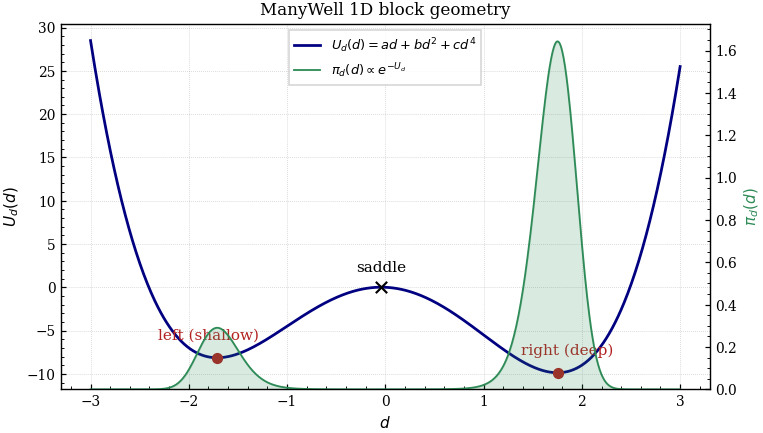

In [14]:
# ── Figure 1: 1D double-well geometry ────────────────────────────────────────
dd = np.linspace(-3, 3, 800)
Ud = U1d_np(dd)
pid = np.interp(dd, _dg, _pd_n)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(dd, Ud, color="navy", lw=1.8, label="$U_d(d)=a d+b d^2+c d^4$")
ax.scatter([D_LEFT, D_RIGHT], [U1d_np(D_LEFT), U1d_np(D_RIGHT)],
           color="firebrick", zorder=5, s=40)
ax.scatter([D_SADDLE], [U1d_np(D_SADDLE)], color="black", marker="x", s=55, zorder=5)
ax.annotate("left (shallow)", (D_LEFT, U1d_np(D_LEFT)),
            textcoords="offset points", xytext=(-6, 12), ha="center", color="firebrick")
ax.annotate("right (deep)", (D_RIGHT, U1d_np(D_RIGHT)),
            textcoords="offset points", xytext=(6, 12), ha="center", color="firebrick")
ax.annotate("saddle", (D_SADDLE, U1d_np(D_SADDLE)),
            textcoords="offset points", xytext=(0, 10), ha="center")
ax.set_xlabel("$d$"); ax.set_ylabel("$U_d(d)$")
ax.set_title("ManyWell 1D block geometry")
ax2 = ax.twinx()
ax2.fill_between(dd, 0, pid, color="seagreen", alpha=0.18)
ax2.plot(dd, pid, color="seagreen", lw=1.2, label="$\\pi_d(d)\\propto e^{-U_d}$")
ax2.set_ylabel("$\\pi_d(d)$", color="seagreen"); ax2.set_ylim(bottom=0)
ax2.grid(False)
l1, lab1 = ax.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2, lab1 + lab2, loc="upper center")
fig.tight_layout(); save_fig(fig, "manywell_1d_geometry")


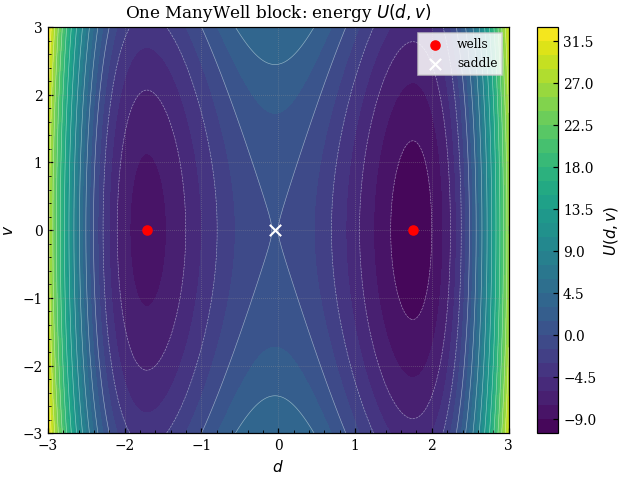

In [15]:
# ── Figure 2: 2D block energy contour U(d,v) = U_d(d) + v^2/2 ────────────────
dv = np.linspace(-3, 3, 300); vv = np.linspace(-3, 3, 300)
DD, VV = np.meshgrid(dv, vv)
E = U1d_np(DD) + 0.5 * VV ** 2
fig, ax = plt.subplots(figsize=(6.0, 4.6))
cf = ax.contourf(DD, VV, E, levels=40, cmap="viridis")
ax.contour(DD, VV, E, levels=15, colors="white", linewidths=0.4, alpha=0.5)
ax.scatter([D_LEFT, D_RIGHT], [0, 0], color="red", marker="o", s=35, zorder=5,
           label="wells")
ax.scatter([D_SADDLE], [0], color="white", marker="x", s=55, zorder=5, label="saddle")
ax.set_xlabel("$d$"); ax.set_ylabel("$v$")
ax.set_title("One ManyWell block: energy $U(d,v)$")
ax.legend(loc="upper right", fontsize=8)
fig.colorbar(cf, ax=ax, label="$U(d,v)$")
fig.tight_layout(); save_fig(fig, "manywell_block_contour")


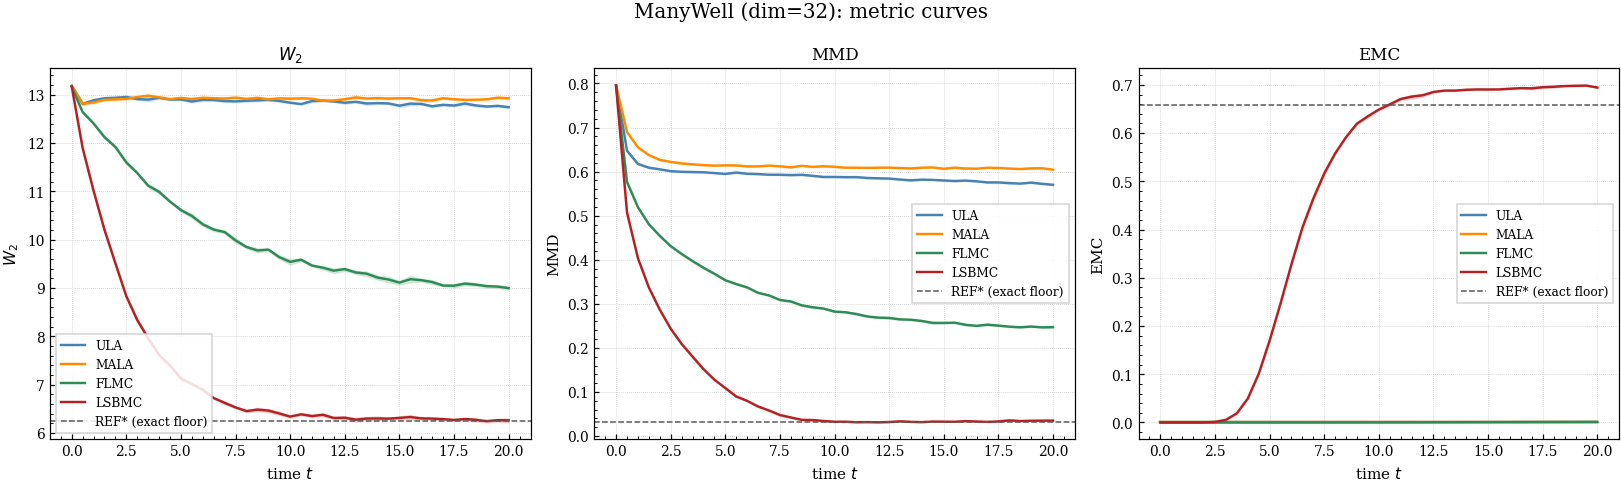

In [16]:
# ── Figure: metric curves over time (W2, MMD, EMC) ───────────────────────────
panels = [("w2",  "$W_2$"),
          ("mmd", "MMD"),
          ("emc", "EMC")]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (key, label) in zip(axes.ravel(), panels):
    for nm in METHODS:
        mean, se = AGG[nm][key]
        ax.plot(T_REC, mean, color=METHOD_COLORS[nm], lw=1.6, label=nm)
        ax.fill_between(T_REC, mean - se, mean + se, color=METHOD_COLORS[nm], alpha=0.15)
    ax.axhline(REF_FLOOR[key], color="0.35", ls="--", lw=1.0, label="REF* (exact floor)")
    ax.set_xlabel("time $t$"); ax.set_ylabel(label); ax.set_title(label)
    ax.legend(fontsize=8)
fig.suptitle(f"ManyWell (dim={DIM}): metric curves", fontsize=13)
fig.tight_layout(); save_fig(fig, "manywell_metrics_curves")


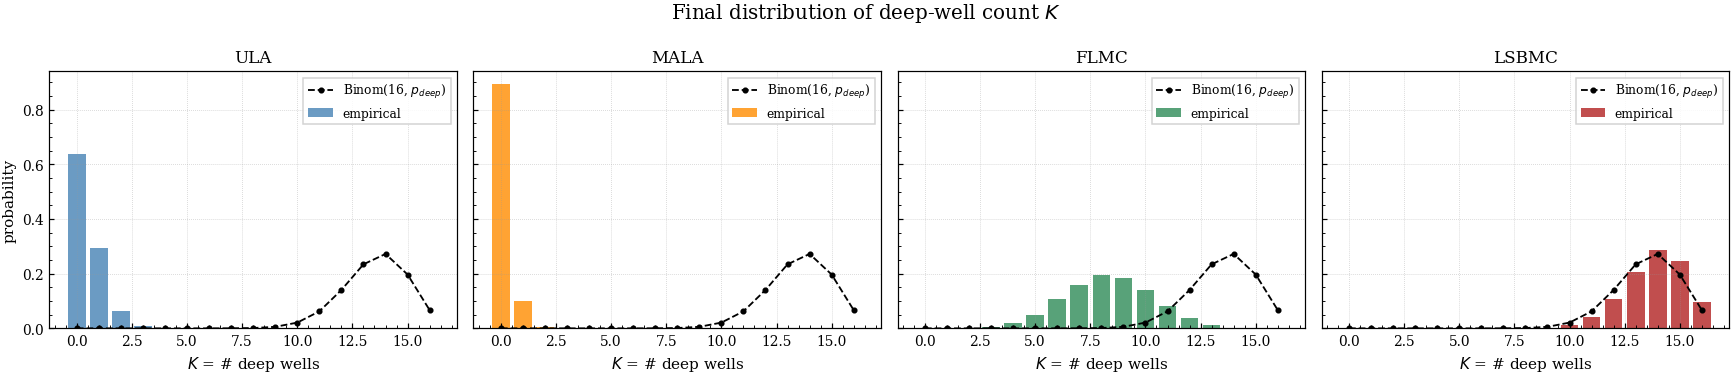

In [17]:
# ── Figure 4: final deep-well count K distribution per method ────────────────
ks = np.arange(N_WELLS + 1)
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)
for ax, nm in zip(axes, METHODS):
    d  = RESULTS[nm]["final"][..., 0::2]
    K  = (d > D_SADDLE).sum(-1).reshape(-1)
    pmf = torch.bincount(K, minlength=N_WELLS + 1).float()
    pmf = (pmf / pmf.sum()).cpu().numpy()
    ax.bar(ks, pmf, color=METHOD_COLORS[nm], alpha=0.8, width=0.8, label="empirical")
    ax.plot(ks, BINOM_PMF, "k--o", ms=3, lw=1.2, label="Binom(16, $p_{deep}$)")
    ax.set_title(nm); ax.set_xlabel("$K$ = # deep wells")
    ax.legend(fontsize=8)
axes[0].set_ylabel("probability")
fig.suptitle("Final distribution of deep-well count $K$", fontsize=13)
fig.tight_layout(); save_fig(fig, "manywell_deep_count_hist")


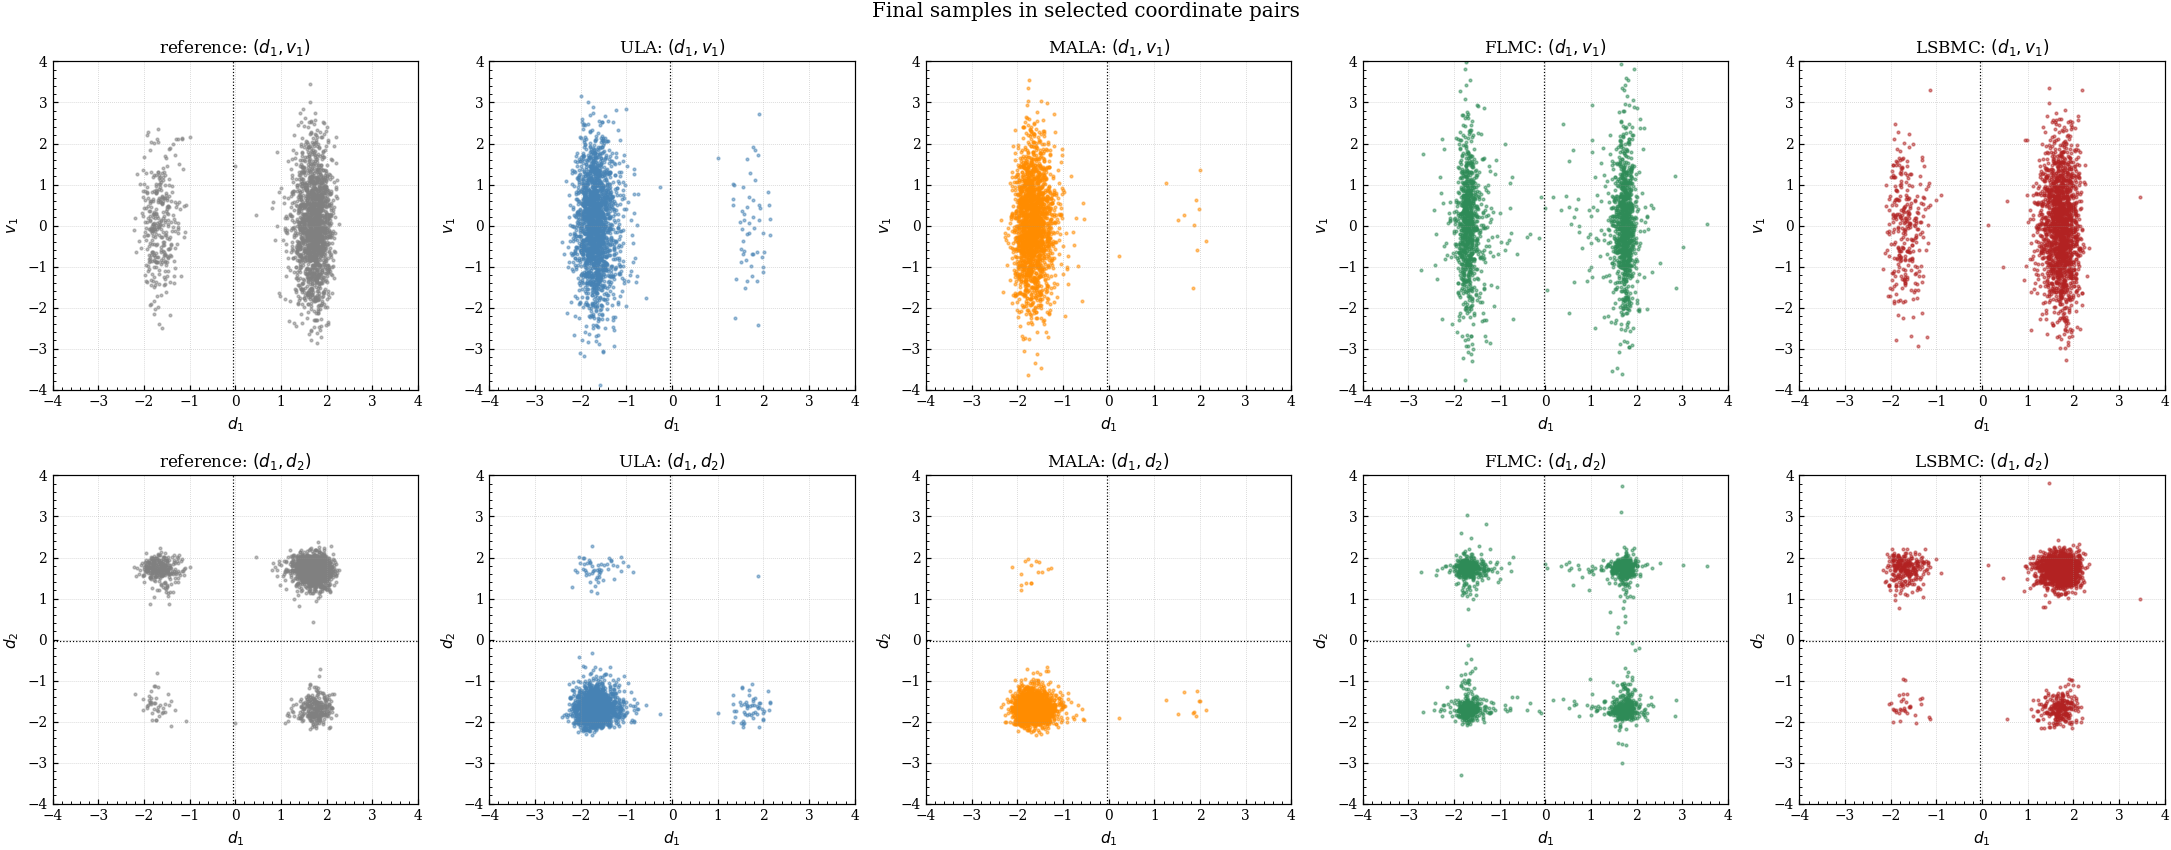

In [18]:
# ── Figure 6: final samples in selected coordinate pairs ─────────────────
ref = X_REF.cpu().numpy()
n_show = 2000
ridx = np.random.default_rng(1).choice(ref.shape[0], n_show, replace=False)

# Columns: reference + one panel per method.  Rows: two coordinate pairs.
COLS  = ["reference"] + METHODS
PAIRS = [((0, 1), "$(d_1, v_1)$", "$d_1$", "$v_1$", False),   # row 0: (d_1, v_1)
         ((0, 2), "$(d_1, d_2)$", "$d_1$", "$d_2$", True)]    # row 1: (d_1, d_2)

fig, axes = plt.subplots(2, len(COLS), figsize=(4 * len(COLS), 8))
for r, ((cx, cy), pair_lab, xlab, ylab, hline) in enumerate(PAIRS):
    for c, nm in enumerate(COLS):
        ax = axes[r, c]
        if nm == "reference":
            ax.scatter(ref[ridx, cx], ref[ridx, cy], s=3, c="0.5", alpha=0.5, rasterized=True)
        else:
            xf  = RESULTS[nm]["final"][0].cpu().numpy()        # seed 0
            idx = np.random.default_rng(0).choice(xf.shape[0], min(n_show, xf.shape[0]), replace=False)
            ax.scatter(xf[idx, cx], xf[idx, cy], s=3, c=METHOD_COLORS[nm], alpha=0.5, rasterized=True)
        ax.axvline(D_SADDLE, color="k", ls=":", lw=0.8)
        if hline:
            ax.axhline(D_SADDLE, color="k", ls=":", lw=0.8)
        ax.set_title(f"{nm}: {pair_lab}"); ax.set_xlabel(xlab); ax.set_ylabel(ylab)
        ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
fig.suptitle("Final samples in selected coordinate pairs", fontsize=13)
fig.tight_layout(); save_fig(fig, "manywell_final_samples_pairs")

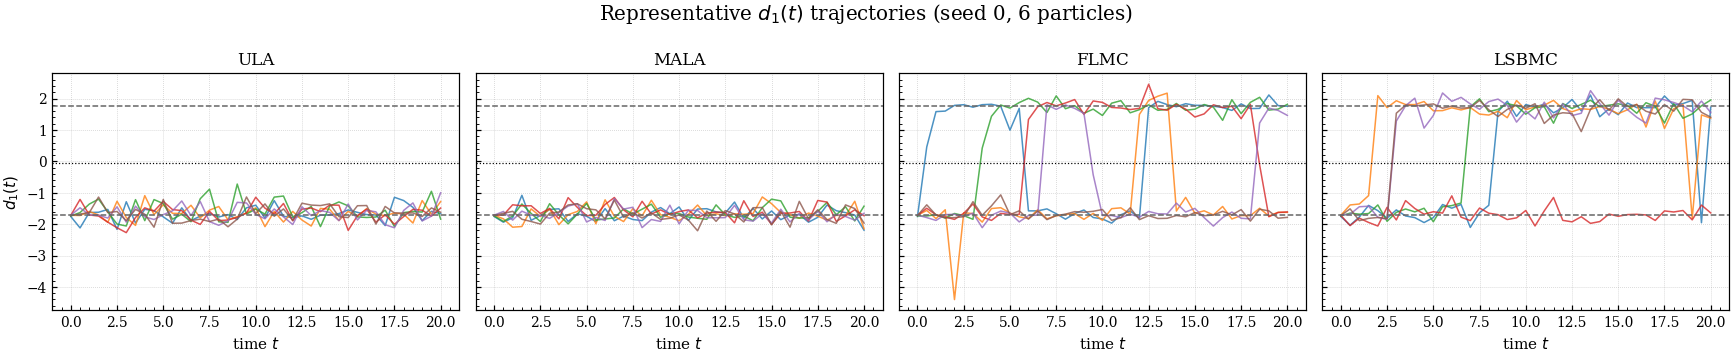

In [19]:
# ── Figure 7 (optional): representative d_1(t) trajectories, seed 0 ──────────
fig, axes = plt.subplots(1, 4, figsize=(16, 3.4), sharey=True)
for ax, nm in zip(axes, METHODS):
    traj = RESULTS[nm]["traj"]                           # (n_check, N_TRAJ, N_TRAJ_BLOCKS)
    for p in range(N_TRAJ):
        ax.plot(T_REC, traj[:, p, 0], lw=1.0, alpha=0.8)
    ax.axhline(D_LEFT,  color="0.4", ls="--", lw=1.0)
    ax.axhline(D_RIGHT, color="0.4", ls="--", lw=1.0)
    ax.axhline(D_SADDLE, color="k",  ls=":",  lw=0.8)
    ax.set_title(nm); ax.set_xlabel("time $t$")
axes[0].set_ylabel("$d_1(t)$")
fig.suptitle(f"Representative $d_1(t)$ trajectories (seed 0, {N_TRAJ} particles)",
             fontsize=13)
fig.tight_layout(); save_fig(fig, "manywell_trajectories")


## Final summary table

In [20]:
# ── Build, print, and save the final summary table ───────────────────────────
def final_ms(nm, key):
    mean, se = AGG[nm][key]
    return mean[-1], se[-1]

rows = []
for nm in METHODS:
    row = {"Method": nm}
    for key, col in [("w2", "W2"), ("mmd", "MMD"), ("emc", "EMC")]:
        m, s = final_ms(nm, key)
        row[col + " (mean)"] = m
        row[col + " (se)"]   = s
    row["MALA acc"]  = RESULTS[nm]["mala_acc"]
    row["Runtime s"] = RESULTS[nm]["runtime"]
    rows.append(row)
df = pd.DataFrame(rows)
df.to_csv(OUT / "final_summary.csv", index=False)

print("=" * 80)
print(f"{'Method':<8}{'W2':>16}{'MMD':>16}{'EMC':>16}{'MALA acc':>12}{'Runtime':>12}")
print("-" * 80)
for nm in METHODS:
    def fmt(key):
        m, s = final_ms(nm, key); return f"{m:.3f}±{s:.3f}"
    acc = f"{RESULTS[nm]['mala_acc']:.3f}" if nm == "MALA" else "—"
    print(f"{nm:<8}{fmt('w2'):>16}{fmt('mmd'):>16}{fmt('emc'):>16}{acc:>12}"
          f"{RESULTS[nm]['runtime']:>11.1f}s")
print("-" * 80)
print(f"{'REF*':<8}{REF_FLOOR['w2']:>16.3f}{REF_FLOOR['mmd']:>16.3f}"
      f"{REF_FLOOR['emc']:>16.3f}{'—':>12}{'—':>12}")
print("=" * 80)
print("REF* = exact iid reference vs reference (finite-sample floor; "
      "best achievable at these subsample sizes)")
print(f"MALA acceptance rate = {RESULTS['MALA']['mala_acc']:.3f} (MALA_DT={MALA_DT})")
print(f"\nSaved -> {OUT/'final_summary.csv'}")
df


Method                W2             MMD             EMC    MALA acc     Runtime
--------------------------------------------------------------------------------
ULA         12.741±0.020     0.570±0.002     0.000±0.000           —        2.9s
MALA        12.925±0.029     0.604±0.001     0.000±0.000       0.982        5.1s
FLMC         8.996±0.033     0.247±0.001     0.001±0.000           —        2.7s
LSBMC        6.260±0.044     0.035±0.001     0.695±0.001           —        2.9s
--------------------------------------------------------------------------------
REF*               6.255           0.032           0.659           —           —
REF* = exact iid reference vs reference (finite-sample floor; best achievable at these subsample sizes)
MALA acceptance rate = 0.982 (MALA_DT=0.01)

Saved -> manywell_output/final_summary.csv


,Method,W2 (mean),W2 (se),MMD (mean),MMD (se),EMC (mean),EMC (se),MALA acc,Runtime s
0,ULA,12.740919,0.020487,0.570184,0.001577,1.856299e-12,2.238065e-14,NaN,2.897335
1,MALA,12.924955,0.029174,0.604450,0.000644,2.765442e-13,1.915487e-15,0.982028,5.141367
2,FLMC,8.996141,0.033188,0.247204,0.001225,1.119838e-03,7.487864e-06,NaN,2.729436
3,LSBMC,6.260421,0.044222,0.035128,0.001171,6.945052e-01,1.224982e-03,NaN,2.932572
